In [33]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.datasets import load_iris
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.cluster import KMeans

# Day 18 - Indian Movie data set

In [34]:
import pandas as pd
mv = pd.read_csv("indian_movies.csv")
mv

,title,genres,director,cast,rating,year
0,3 Idiots,Comedy Drama,Rajkumar Hirani,Aamir Khan R. Madhavan Sharman Joshi,8.4,2009
1,Dangal,Biography Drama,Siddharth Anand,Aamir Khan Fatima Sana Shaikh,8.3,2016
2,PK,Comedy Drama,S. S. Rajamouli,Aamir Khan Anushka Sharma,8.1,2014
3,Lagaan,Drama Sport,Ashutosh Gowariker,Aamir Khan Gracy Singh,8.1,2001
4,Taare Zameen Par,Drama Family,Aamir Khan,Aamir Khan Darsheel Safary,8.4,2007
5,Baahubali: The Beginning,Action Drama,S. S. Rajamouli,Prabhas Rana Daggubati,8.0,2015
6,Baahubali 2: The Conclusion,Action Drama,S. S. Rajamouli,Prabhas Anushka Shetty,8.2,2017
7,RRR,Action Drama,S. S. Rajamouli,Ram Charan N. T. Rama Rao Jr.,8.0,2022
8,Chennai Express,Comedy Romance,Rohit Shetty,Shah Rukh Khan Deepika Padukone,6.9,2013
9,Dilwale Dulhania Le Jayenge,Romance Drama,Aditya Chopra,Shah Rukh Khan Kajol,8.0,1995


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data cleaning

In [46]:
mv = mv[['title', 'genres', 'director', 'year', 'rating',]]
mv.dropna(inplace=True)
mv

,title,genres,director,year,rating
0,3 Idiots,Comedy Drama,Rajkumar Hirani,2009,8.4
1,Dangal,Biography Drama,Siddharth Anand,2016,8.3
2,PK,Comedy Drama,S. S. Rajamouli,2014,8.1
3,Lagaan,Drama Sport,Ashutosh Gowariker,2001,8.1
4,Taare Zameen Par,Drama Family,Aamir Khan,2007,8.4
5,Baahubali: The Beginning,Action Drama,S. S. Rajamouli,2015,8.0
6,Baahubali 2: The Conclusion,Action Drama,S. S. Rajamouli,2017,8.2
7,RRR,Action Drama,S. S. Rajamouli,2022,8.0
8,Chennai Express,Comedy Romance,Rohit Shetty,2013,6.9
9,Dilwale Dulhania Le Jayenge,Romance Drama,Aditya Chopra,1995,8.0


# Genre Distributing

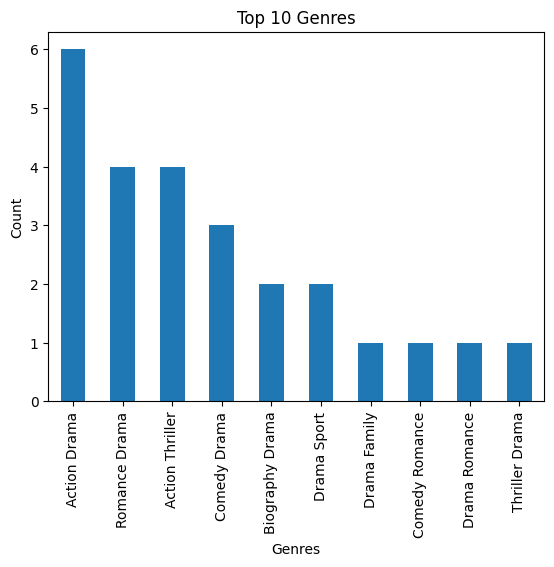

In [37]:
plt.figure()
mv['genres'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.show()

# Rating Distributions

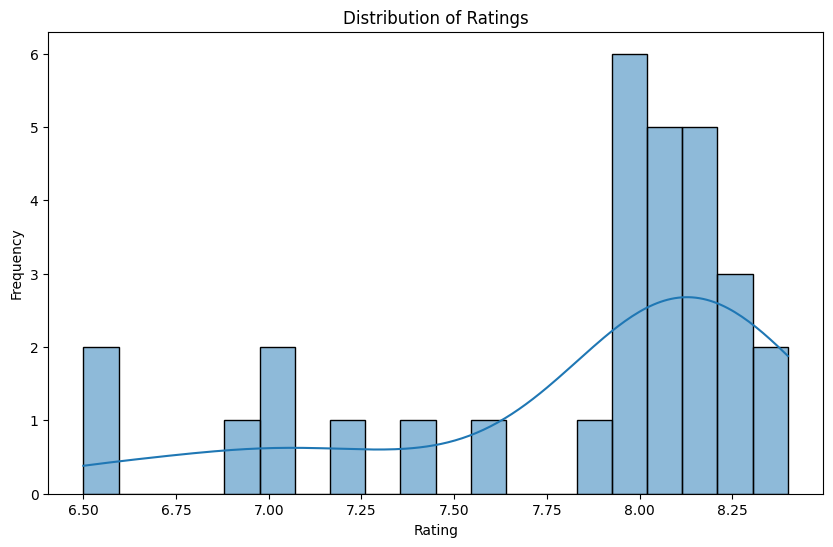

In [38]:
plt.figure(figsize=(10,6))
sns.histplot(mv["rating"], bins=20, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

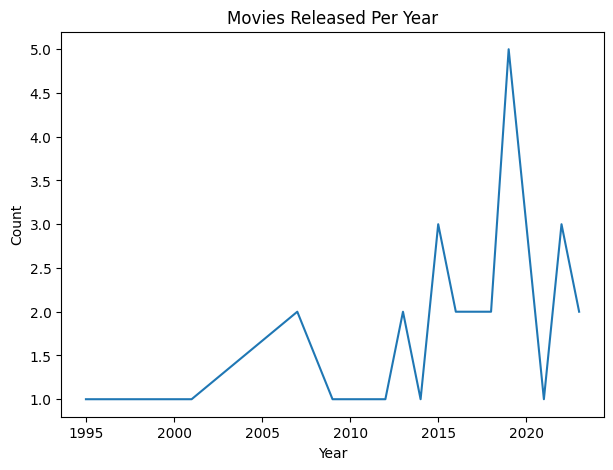

In [39]:
#Movie Per year
plt.figure(figsize=(7,5))
mv['year'].value_counts().sort_index().plot(kind='line')
plt.title('Movies Released Per Year')
plt.xlabel('Year')      
plt.ylabel('Count')
plt.show()  

In [54]:
mv['combined'] = mv['genres'] + " " + mv['director'] + " " + mv['year'] .astype(str)
mv

,title,genres,director,year,rating,combined
0,3 Idiots,Comedy Drama,Rajkumar Hirani,2009,8.4,Comedy Drama Rajkumar Hirani 2009
1,Dangal,Biography Drama,Siddharth Anand,2016,8.3,Biography Drama Siddharth Anand 2016
2,PK,Comedy Drama,S. S. Rajamouli,2014,8.1,Comedy Drama S. S. Rajamouli 2014
3,Lagaan,Drama Sport,Ashutosh Gowariker,2001,8.1,Drama Sport Ashutosh Gowariker 2001
4,Taare Zameen Par,Drama Family,Aamir Khan,2007,8.4,Drama Family Aamir Khan 2007
5,Baahubali: The Beginning,Action Drama,S. S. Rajamouli,2015,8.0,Action Drama S. S. Rajamouli 2015
6,Baahubali 2: The Conclusion,Action Drama,S. S. Rajamouli,2017,8.2,Action Drama S. S. Rajamouli 2017
7,RRR,Action Drama,S. S. Rajamouli,2022,8.0,Action Drama S. S. Rajamouli 2022
8,Chennai Express,Comedy Romance,Rohit Shetty,2013,6.9,Comedy Romance Rohit Shetty 2013
9,Dilwale Dulhania Le Jayenge,Romance Drama,Aditya Chopra,1995,8.0,Romance Drama Aditya Chopra 1995


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

In [68]:
#Converting text into numerical Form
tfidf = TfidfVectorizer(stop_words='english')
tfidf_Matrix = tfidf.fit_transform(mv['combined'])



In [69]:
#Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(tfidf_Matrix)
mv['cluster'] = kmeans.labels_
mv[['title', 'cluster']].head(10)  

,title,cluster
0,3 Idiots,4
1,Dangal,0
2,PK,4
3,Lagaan,3
4,Taare Zameen Par,2
5,Baahubali: The Beginning,0
6,Baahubali 2: The Conclusion,0
7,RRR,0
8,Chennai Express,4
9,Dilwale Dulhania Le Jayenge,1


In [70]:
#Calculating Cosine Similarity
similarity = cosine_similarity(tfidf_Matrix)
similarity

array([[1.        , 0.03407314, 0.21788231, 0.03000439, 0.03082392,
        0.04627524, 0.04453094, 0.04627524, 0.13581108, 0.03145715,
        0.03145715, 0.        , 0.03198421, 0.0382146 , 0.03069029,
        0.0330594 , 0.        , 0.14464375, 0.03548469, 0.03634855,
        0.        , 0.        , 0.02735099, 0.03138508, 0.        ,
        0.03426387, 0.03213555, 0.18591431, 0.03145715, 0.03121006],
       [0.03407314, 1.        , 0.04383924, 0.03275686, 0.03365157,
        0.05052033, 0.04861602, 0.05052033, 0.        , 0.03434289,
        0.03434289, 0.45085362, 0.0349183 , 0.04172024, 0.03350568,
        0.03609213, 0.        , 0.        , 0.0387399 , 0.03968301,
        0.        , 0.        , 0.24045435, 0.03426421, 0.47616456,
        0.30122848, 0.03508353, 0.03740709, 0.03434289, 0.03407314],
       [0.21788231, 0.04383924, 1.        , 0.0386043 , 0.03965873,
        0.36067615, 0.34708084, 0.36067615, 0.17473749, 0.04047345,
        0.04047345, 0.        , 0.04115158, 0.

In [84]:
def recommend(movie_name, top_n=7):
    if movie_name not in mv['title'].values:
        print("Movie not found in the dataset.")
        return 
    idx = mv[mv['title'] == movie_name].index[0]
    distances = list(enumerate(similarity[idx]))
    sorted_movies = sorted(distances, key=lambda x: x[1], reverse=True)[1:top_n+1]
    print(f"Top {top_n} movies similar to '{movie_name}': \n")
    for i in sorted_movies:
        print(f".... {mv.iloc[i[0]].title}")
recommend("3 Idiots")
# recommend("Drishyam")

Top 7 movies similar to '3 Idiots': 

.... PK
.... Queen
.... Bhool Bhulaiyaa
.... Chennai Express
.... Baahubali: The Beginning
.... RRR
.... Baahubali 2: The Conclusion
